# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

### Import and load the data

In [1]:
# Imports
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



In [91]:
# Import and preprocess data
# Some functions below are obtained from assignment 7 (course material)
# TO DO: 15 iterations do not always form a single trial! sometimes it is less. Adjust the code

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))     # [111, 112, 113, 114, 115, 116]
    non_target_ids = list(range(101, 107)) # [101, 102, 103, 104, 105, 106]

    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    # {'Word_1/Target': 111, 'Word_2/Target': 112, 'Word_3/Target': 113, 'Word_4/Target': 114, 'Word_5/Target': 115, 'Word_6/Target': 116}
    
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    # Same idea for non targets
    
    evs = mne.events_from_annotations(raw)[0]
    # print(evs.shape) # e.g. (548,3)
    # print(evs)
    # e.g.
    # [[    0      0  99999]
    # [  4688      0    203]
    # [  9436      0    103]
    # ...
    # [267206      0    106]
    # [267559      0    103]
    # [270989      0    255]]

    # Turn off baseline correction 
    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                       proj=False, tmax=1, baseline=None)
    return epoch

# added
def all_have_same_condition(data_path, show_conditions = False, selection = None):
    """ Checks if all runs within a session have the same condition (6D vs HP, 350 vs 250)"""

    # data_path = "data_p1/P1_S3/anonymized" 
    data_dir = Path.cwd() / data_path
    if selection is None:
        header_files = data_dir.glob("auditoryAphasia*.vhdr") 
    else:
        header_files = data_dir.glob("auditoryAphasia_" + selection + "*.vhdr") 
        
    header_files_list = list(header_files) # convert generator object into list
    header_files_names = [header.name for header in header_files_list] # obtain all headers as strings

    # parse condition of all header files (i.e., all runs)
    header_conditions_1 = [header.split("_")[1] for header in header_files_names] # first condition: 6D or HP
    header_conditions_2 = [header.split("_")[2] for header in header_files_names] # second condition: 350 or 250

    if show_conditions:
        print(header_conditions_1)
        print(header_conditions_2)

    return len(set(header_conditions_1))==1 and len(set(header_conditions_2))==1

# added
def list_iterations(raw_data):
    """
    For a single run containing 6 trials, compute for each trial the nr of iterations used (this is not always 15!)
    Returns a list of 6 elements, e.g. [15 15 8 15 14 15]
    """

    evs = mne.events_from_annotations(raw_data)[0] 
    markers = evs[:,2] # list all event_ids

    # obtain all unique event markers
    uniques, first_indices, counts = np.unique([x for x in markers], return_index=True, return_counts=True)

    # Only keep trial start markers [200, 201, 202, 203, 204, 205] and the run end marker 255
    only_starter_markers = [x for x in uniques if x>199 and x<206 or x==255]
    only_starter_markers_indices = [first_indices[np.where(uniques==x)][0] for x in uniques if x>199 and x<206 or x==255]

    # Sort the markers according to their stimulus onset order in the trial
    sorted_starter_markers = [x for _,x in sorted(zip(only_starter_markers_indices,only_starter_markers))] 
    sorted_starter_markers_indices = np.sort(only_starter_markers_indices)

    stimuli_per_trial = np.diff(sorted_starter_markers_indices)-1
    iterations_per_trial = stimuli_per_trial/6

    return iterations_per_trial

# added
def load_complete_session(data_path, selection = None, discard_channels = None):
    """Load data of a complete session; return trials"""

    # data_dir = Path.cwd() / "data_p1/P1_S1/anonymized" 
    data_dir = Path.cwd() / data_path
    if selection is None:
        header_files = data_dir.glob("auditoryAphasia*.vhdr") # assuming the condition within a session is the same
        print("All conditions of this session are the same: ", all_have_same_condition(data_path)) # either True or False
    else:
        assert isinstance(selection, str), "given selection parameter is not an instance of String" 
        header_files = data_dir.glob("auditoryAphasia_" + selection + "*.vhdr")    
        print("All conditions of the selected runs of this session: ",all_have_same_condition(data_path, show_conditions=True, selection=selection))

    # Load the data, preprocess and slice it into epochs
    epochs = list()

    # added: per run, store how many iterations were used for every trial in that run
    all_trial_iterations = list() 
    print("Number of iterations per trial:")
    run_count = 0 # added to keep track of runs

    for f in header_files:
        raw_data = load_and_preprocess_raw(f)

        # discard channels (eventually move this feature into load_and_preprocess_raw?)
        if discard_channels:
            channels_to_discard = ["AF7","AF3","AF4","AF8","F5","F1","F2","F6","FT7","FC3","FCz","FC4","FT8","C5","C1","C2","C6","TP7","CP3","CPz","CP4","TP8","P5","P1","P2","P6","PO7","PO5","POz","PO6","PO8","Oz"] # same as Ch33 - Ch64
            raw_data = raw_data.drop_channels(channels_to_discard)

        epochs.append(epoch_raw(raw_data))

        # added
        iterations_per_trial = list_iterations(raw_data) # obtain list with nr of iterations per trial for all six trials;
        print("Run {}: {}".format(run_count, iterations_per_trial))
        all_trial_iterations.append(iterations_per_trial.astype(int)) # store this per-run iteration counter list 
        run_count+=1

    # Overwrite epochs list to save memory
    epochs = mne.concatenate_epochs(epochs) 

    # Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
    iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to final epoch in steps of 6

    # Assert that each iteration contains exactly 1 Target
    assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

    # Old (of assignment 7) and incorrect for this dataset:
    # The assumption was that 15 iterations form a single trial
    # trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)] # [  0  15  30  45 ... 465 480 495]

    # Correct: It is not always the case that 15 iterations form a single trial. Sometimes less iterations were recorded, due to dynamic stopping
    # Group the correct amount of iterations per trial
    trials = []
    all_trial_iterations = np.concatenate(all_trial_iterations) # flatten all per-run iteration counter lists to a single 1D array
    idx = 0
    for n_iters in all_trial_iterations:
        trials.append(iterations[idx : idx + n_iters])
        idx += n_iters

    return trials, iterations, epochs

# added
def inspect_session(data_path):
    """Inspect data of a complete session, print relevant information"""

    # data_dir = Path.cwd() / "data_p1/P1_S1/anonymized" 
    data_dir = Path.cwd() / data_path
    header_files = data_dir.glob("auditoryAphasia*.vhdr") # assuming the condition within a session is the same
    print("Condition per run: ")
    print("All conditions of this session are the same: ", all_have_same_condition(data_path, show_conditions=True)) # print conditions

    # Per run, print how many iterations were used for every trial in that run
    print("Number of iterations per trial:")
    run_count = 0 # added to keep track of runs

    for f in header_files:
        raw_data = load_and_preprocess_raw(f)
        iterations_per_trial = list_iterations(raw_data) # obtain list with nr of iterations per trial for all six trials;
        print("Run {}: {}".format(run_count, iterations_per_trial.astype(int)))
        run_count+=1

# added 
def get_n_epochs(trials):
    """"Returns the total number of epochs found in the given trials"""
    n_epochs = 0
    for trial in trials:
        for iteration in trial:
            n_epochs += 6
    return n_epochs

# added
def get_iterations(trials):
    """Returns the lists of iterations found in the given trials"""
    n_iterations = list()
    for trial in trials:
        n_iterations.append(len(trial))
    n_iterations = np.array([n_iterations[i:i+6] for i in np.arange(0, len(trials),6)])
    return n_iterations

# added
def get_n_iterations(trials):
    """"Returns the total amount of iterations found in the given trials"""
    return np.sum(get_iterations(trials))

In [88]:
# added this whole block
# Object serialization (storing objects with pickle)
import pickle
import os
import re

# Example usage of pickl (to be removed) -----------------------------------------
# test_list = ["Hi", "this", "is", "a", "test"]
# with open("test.pkl",'wb') as f:
#     pickle.dump(test_list,f) # store the list
# f.close()    
# with open("test.pkl", 'rb') as f:
#     test_list_loaded = pickle.load(f) # load the list
# f.close()    
# print(test_list)
# print(test_list_loaded)
# --------------------------------------------------------------------------------

## Functions to store data in pickl files

def safe_filename(session_path):
    """replace / and \\ in data paths by underscores (to make a valid file name)"""
    return re.sub(r"[\\/]", "_", session_path)

 
# Note: when changing something in the loading/preprocessing, the stored pickl files should be removed as they are outdated.
# to do: figure out if the note above can be done automatically 
def load_session_chached(session_path, cache_dir="cache/", selection = None, discard_channels = False):
    """Load the current trials either for the first time, saving it as a .pkl or if one exists, directly load from a .pkl file
    
    For visualization purposes, the `iterations` and `epochs` is also returned. However, this takes substantially more memory when storing, so these two features/returns might be removed later
    """

    os.makedirs(cache_dir, exist_ok=True)
    safe_name = safe_filename(session_path=session_path) # replace \ and / by _
    print("Loading file: ",safe_name)
    if selection is None:
        if not discard_channels:
            cache_path = os.path.join(cache_dir, safe_name + ".pkl")
        else:
            cache_path = os.path.join(cache_dir, safe_name + "_dc" + ".pkl")    
    else:    
        assert isinstance(selection, str), "selection is not an instance of String"
        if not discard_channels:
            cache_path = os.path.join(cache_dir, safe_name + selection + ".pkl")
        else:
            cache_path = os.path.join(cache_dir, safe_name + selection + "_dc" + ".pkl")    

    print("Corresponding .pkl file: ",cache_path)

    # check if a .pkl file for that session already exists
    if os.path.exists(cache_path):
        print("A .pkl file already exists. Loading the data from {}".format(cache_path))
        with open(cache_path, 'rb') as f:
            trials = pickle.load(f)
            iterations = pickle.load(f)
            epochs = pickle.load(f)

    # if not, then load the data and store it in a new .pkl file 
    else:
        print("A .pkl file does not exist yet. Loading the data and creating {}... (this might take a few mins)".format(cache_path))
        trials, iterations, epochs = load_complete_session(session_path, selection, discard_channels)  
        with open(cache_path, 'wb') as f:
            pickle.dump(trials, f)
            pickle.dump(iterations, f)
            pickle.dump(epochs, f)
            
    return trials, iterations, epochs



### Dataset



For patient_1, 18 sessions were recorded, of which session 1, 2, and 18 are offline, and sessions 3-17 are online. Each session contains a varying number of blocks. Each block usually contains 6 runs. However, the last block of a session may contain less runs.

For every run a `.eeg`, `.vhdr` and `.vmrk` file is provided. 

The `.vhdr` file of P1, S1, Block1, Run1 contains the following information:
- number of channels: 69
- sampling rate: 1000 Hz
- frequency range: [0-250 Hz]
- the channels are the exact same as of the data of assignment 7.

Note that in the online sessions (session 3-17), the number of EEG channels is not 63, but 31.

The following channels are non-EEG channels (description from A7):
* The EMG channel records an electromyogram. This is muscle activity.
* The GSR channel records the galvanic skin response. This is sweat gland activity which is indicative of stress levels and excitation.
* The Respi channel records respiration activity.
* The Pulse channel records the heart pulses by shining a red light on the finger and recording how much of it is reflected back.
* The Optic channel is an optical sensor focused on a portion of the screen that flashes every time an event happens in order to detect potential interference/delay between the time point the computer issues a stimulus and the time the stimulus is actually presented on the screen to the user.

Some of these channels can be used to remove artefacts from the EEG signal and better phase-locking the signals. For the experiment in assignment 7 though they aren't relevant. Is that also the case for my thesis project?

In the `.vhdr` files there is also the resolution ( $\mu V$ steps) of each channel. The ``S o f t w a r e  F i l t e r s`` (line 177) is different from that of A7. In A7, the impedance (kOhm) per channel is provided, while in the patient data this information is replaced by `???`.

In the `.vmrk` file marker information is found about the events.

### Session 3
First load and preprocess the data

Then measure classification performance offline

Then measure classification performance in an online simulation


#### load & preprocess the data

In [55]:
# Load all runs of session 3
data_path_test = "data_p1/P1_S3/anonymized" 
# For S1 and S2, set selection parameter to "6D_long_350" to select only runs with this condition
# For all online sessions, selection = None (default)
trials, iterations, epochs = load_session_chached(data_path_test, selection = None)

# for p1 s3, first runtime is 4-5 min
# for p1 s3, second runtime is 10 s

print(len(trials))
print(all_have_same_condition(data_path_test, show_conditions=True))


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
84
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350']
True


In [56]:
# Printing the objects for visualisation
# print("epochs = \n",epochs_s3)
# print("\nlen(epochs) = ", len(epochs_s3))
# print("len(iterations) = ", len(iterations_s3), " (each consists of 6 epochs)")
# print("len(trials) = ", len(trials_s3), " (each consists of 15 iterations or less)")
# print(get_n_epochs(trials_s3))
# print(get_n_iterations(trials_s3))
# print(get_iterations(trials_s3))


#### Visualizing ERPs

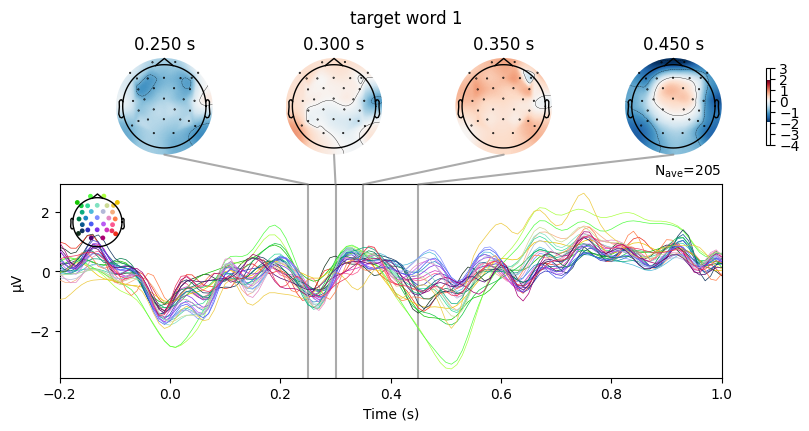

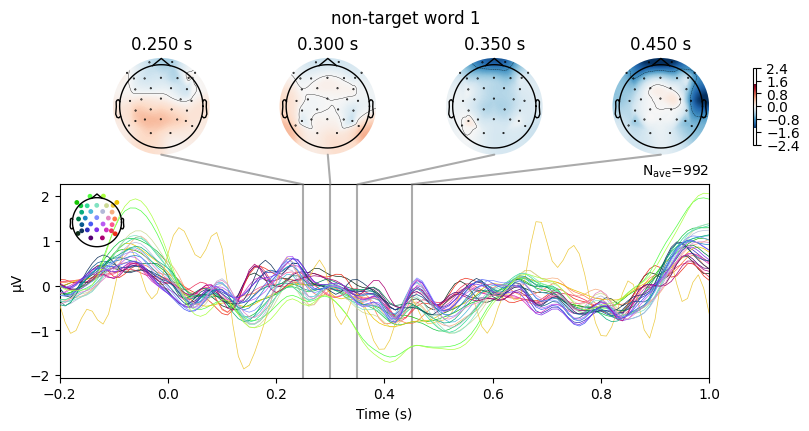

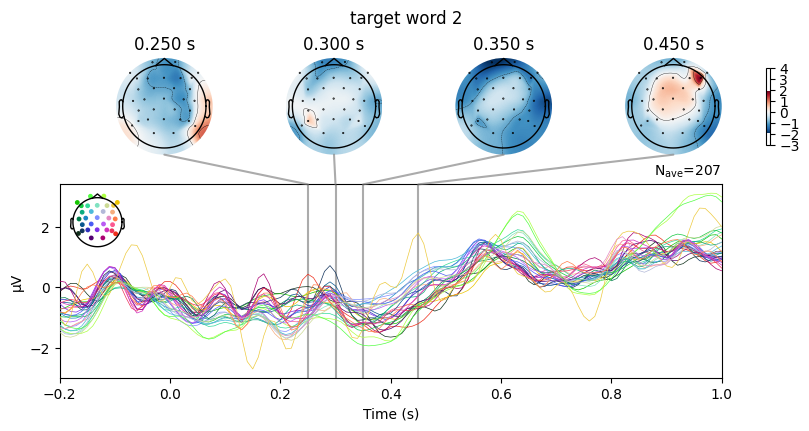

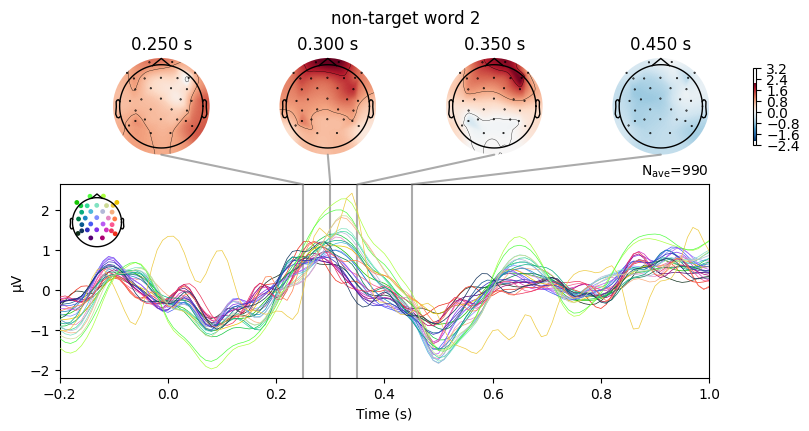

In [ ]:
scalp_times = (0.25, 0.30, 0.35, 0.45)
for i in np.arange(1,6):
    if i < 3:     # to not have a massive notebook
        epochs[f'Word_{i}']["Target"].average().plot_joint(title=f'target word {i}', times=scalp_times)
        epochs[f'Word_{i}']["NonTarget"].average().plot_joint(title=f'non-target word {i}', times=scalp_times)

plt.show()


In [7]:
# Ignore
# This whole block should be ignored, it was for my own understanding

# Get the data path of session 3
data_dir = Path.cwd() / "data_p1/P1_S3/anonymized" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")

counter = 0 # to be removed
raw_data_storage = list() # added for insight - (to be removed later)

for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    raw_data_storage.append(raw_data) # added for insight - (to be removed later)
    counter+=1 # to be removed

# Printing the objects for visualisation
print(len(raw_data_storage))
print(raw_data_storage[0].info)

14
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 31 EEG
 custom_ref_applied: False
 dig: 34 items (3 Cardinal, 31 EEG)
 highpass: 0.5 Hz
 lowpass: 16.0 Hz
 meas_date: 1920-01-01 15:06:42 UTC
 nchan: 31
 projs: []
 sfreq: 1000.0 Hz
>


## Calibration (Offline)
Using the data of session 3

#### Functions

In [59]:
# comparing LDA - BT-LDA - sLDA
# data is in channel prime order
# evaulation method added from Jan's example_toeplitz_lda_simple.py

from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
import warnings

# See cell block in dump file for documentation on how this function works
def get_jumping_means(epo, boundaries):
    """Feature extraction by averaging over time intervals between the given 'boundaries' """
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

def compare_auc_single_trial_interval(trials, start=0, stop=12, test_size=0.2, only_auc = True, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), plot_roc_curves = True):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    
    calibration data is determined by a selection of trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters. You can check this by passing different values for [start - stop]
    The full dataset here is the selected interval of calibration data. This interval will be split with sklearn's train_test_split method.

    input:
    - trials: list of all trials
    - start: first trial to take as calibration data
    - stop: last trial to take as calibration data
    - test_size: the test part in the ratio train:test when splitting the calibration data. 
    - only_auc: if True, only the auc scores are printed for all three classifiers. If False, then the balanced auc scores are printed too.
    - ival_bounds: time interval boundaries to average the raw calibration trials over
    - plot_roc_curves: if True, also plot the ROC curves. if False, then only the AUC scores are printed. 
    """

    ### Feature extraction ------------------------------------------------------------

    if stop is None:
        stop = len(trials)
    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds

    # Switching to lists instead of np arrays because of inconsistent amounts of iterations per trial (no homogeneous shape)
    calibration_trials = [[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials]
    calibration_trials_reshaped = [
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ]

    # Reshaping to feed into classifier
    # Changes implemented as we are using lists instead of np arrays
    calibration_stimuli = list()

    # flatten into input for classifier
    for trial in calibration_trials_reshaped:
        for iteration in trial:
            for epoch in iteration:
                # flatten each epoch from 2D (n_time_ivals, n_channels) to 1D (n_time_ivals * n_channels) 
                calibration_stimuli.append(epoch.reshape(-1)) 

    calibration_stimuli = np.array(calibration_stimuli) # shape (samples,features),  e.g. (1038, 124)
    # print("calibration_stimuli.shape: ", calibration_stimuli.shape)

    calibration_labels = list()
    # obtain flattened labels 
    for trial in raw_calibration_trials:
        for iteration in trial:
            for event in iteration.events[:,2]:
                calibration_labels.append(1 if event > 107 else 0)
    
    calibration_labels = np.array(calibration_labels) # contains only 0's and 1's
    #print(calibration_labels.shape) # shape (samples,) e.g. (1038,)

    ### Evaluation --------------------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=test_size, shuffle=False)

    # Evaluation of Jan's simple toeplitz example script

    print("AUC scores computed using a single train_test_split with test_size = {}".format(test_size))

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC LDA: ", roc_auc_lda)
    else:
        print("LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_lda)
        print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC SLDA: ", roc_auc_slda)
    else:     
        print("\nsLDA scores with channel prime data")
        print("roc_auc: ",roc_auc_slda)
        print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    if only_auc:
        print("AUC BT-LDA: ", roc_auc_btlda)
    else:    
        print("\nBT-LDA scores with channel prime data")
        print("roc_auc: ",roc_auc_btlda)
        print("bal_acc_auc: ",bal_acc_auc_btlda)

    # comparing LDA - BT-LDA - sLDA using other evaluation method (of assignment 07, exercise 3)
    if plot_roc_curves:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

        ### LDA
        lda = LDA()
        ldaclf = lda.fit(X_train, y_train)
        fpr_lda, tpr_lda, thresholds_lda = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        metrics.RocCurveDisplay(fpr=fpr_lda, tpr=tpr_lda).plot(ax=axes[0])
        axes[0].plot([0, 1],[0,1], '--') 
        axes[0].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
        axes[0].set_title("AUC-ROC of LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))

        ### Shrinkage LDA
        slda = LDA(solver='lsqr',shrinkage = 'auto')
        slda.fit(X_train, y_train)

        fpr_slda, tpr_slda, thresholds_slda = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_slda, tpr=tpr_slda).plot(ax=axes[1])
        axes[1].plot([0, 1],[0,1], '--')
        axes[1].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
        axes[1].set_title("AUC-ROC of sLDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))

        ### BT-LDA
        nch = (trials[0][0]).info["nchan"]
        # nch = 31 (for online sessions) and 61 for offline sessions
        btlda = ToeplitzLDA(n_channels= nch) 
        btlda.fit(X_train, y_train) 

        fpr_btlda, tpr_btlda, thresholds_btlda = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
        metrics.RocCurveDisplay(fpr=fpr_btlda, tpr=tpr_btlda).plot(ax=axes[2])
        axes[2].plot([0, 1],[0,1], '--')
        axes[2].legend(['ROC (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
        axes[2].set_title("AUC-ROC of BT-LDA - using trials [{}:{}] - test_size = {}".format(start,stop,test_size))
        
        plt.show()


In [ ]:
# Cross-validation instead of train_test_split
# LDA vs SLDA vs BT-LDA on calibration data

def compute_auc_with_cv(trials=trials, start=0, stop=12, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), cv_folds = 4, show_mean = True, show_folds=False):
    """
    Computes and prints the average AUC score of LDA, SLDA and BTLDA using cross-validation

    input:
    - trials
    - start
    - stop
    - ival_bounds
    - cv_folds
    - show_only_mean: if True, only print the average AUC scores. if False, also print the AUC score of each fold.
    - show_folds: if True, print the AUC scores of all folds. If False, do not print the AUC score per fold
    """

    if stop is None:
        stop = len(trials)
        
    raw_calibration_trials = trials[start:stop]
    #online_trials = trials[12:] 
    clf_ival_boundaries = ival_bounds

    calibration_trials = [[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials]
    calibration_trials_reshaped = [
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ]

    # Reshaping to feed into classifier
    calibration_stimuli = list()

    # flatten into input for classifier
    for trial in calibration_trials_reshaped:
        for iteration in trial:
            for epoch in iteration:
                # flatten each epoch from 2D (n_time_ivals, n_channels) to 1D (n_time_ivals * n_channels) 
                calibration_stimuli.append(epoch.reshape(-1)) 

    calibration_stimuli = np.array(calibration_stimuli) # shape (samples,features),  e.g. (1038, 124)

    calibration_labels = list()
    # obtain flattened labels 
    for trial in raw_calibration_trials:
        for iteration in trial:
            for event in iteration.events[:,2]:
                calibration_labels.append(1 if event > 107 else 0)
    
    calibration_labels = np.array(calibration_labels) # contains only 0's and 1's
    #print(calibration_labels.shape) # shape (samples,) e.g. (1038,)
    X = calibration_stimuli
    y = calibration_labels

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    auc_lda = cross_val_score(clf_lda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of LDA, all {} folds: {}".format(cv_folds, auc_lda))
    if show_mean:    
        print("Mean AUC score of LDA: \t\t", auc_lda.mean())

    ### SLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    auc_slda = cross_val_score(clf_slda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of sLDA, all {} folds: {}".format(cv_folds, auc_slda))
    if show_mean:     
        print("Mean AUC score of sLDA: \t", auc_slda.mean())

    ### BT-LDA
    #nch = 31
    nch = (trials[0][0]).info["nchan"]
    clf_btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    auc_btlda = cross_val_score(clf_btlda, X, y, cv=cv_folds, scoring = 'roc_auc')
    if show_folds:
        print("AUC score of BT-LDA, all {} folds: {}".format(cv_folds, auc_btlda))
    if show_mean:    
        print("Mean AUC score of BT-LDA: \t", auc_btlda.mean())



#### Function call

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5160581473968897
AUC SLDA:  0.4964503042596349


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


AUC BT-LDA:  0.5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


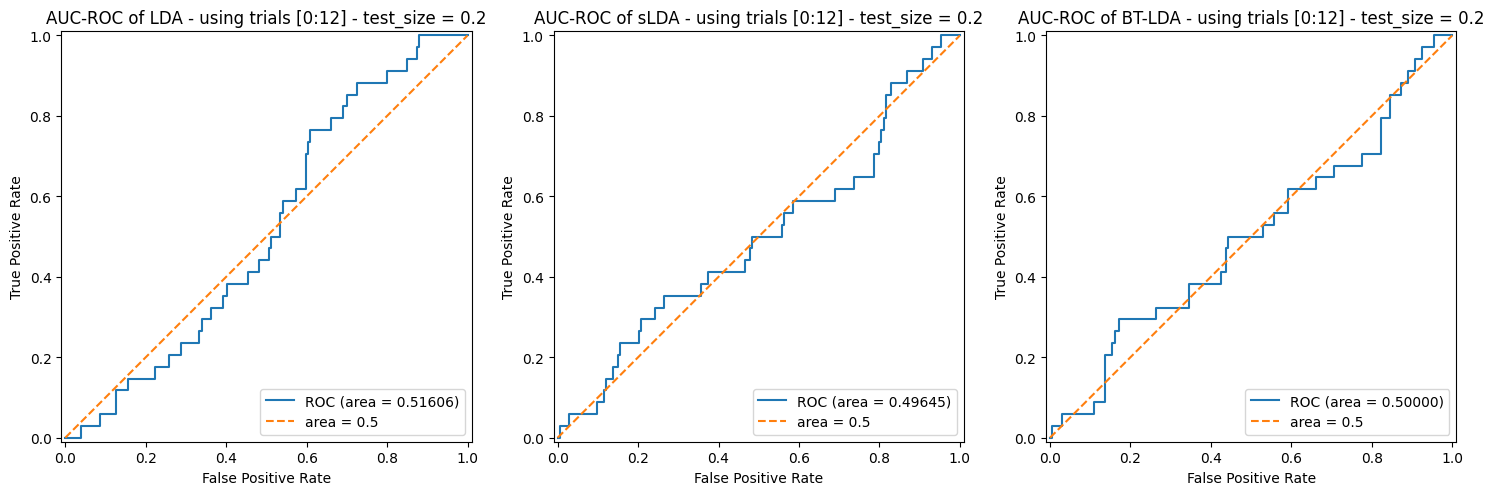

In [ ]:
# Calibration/offline performance

# train_test_split using test_size = 0.2 and trials 0-12
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(trials_s3, 0, 12, test_size=0.2, ival_bounds=clf_ival_boundaries, plot_roc_curves=True) 

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5759714345725687
AUC SLDA:  0.573492963663096
AUC BT-LDA:  0.5789119932787229


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


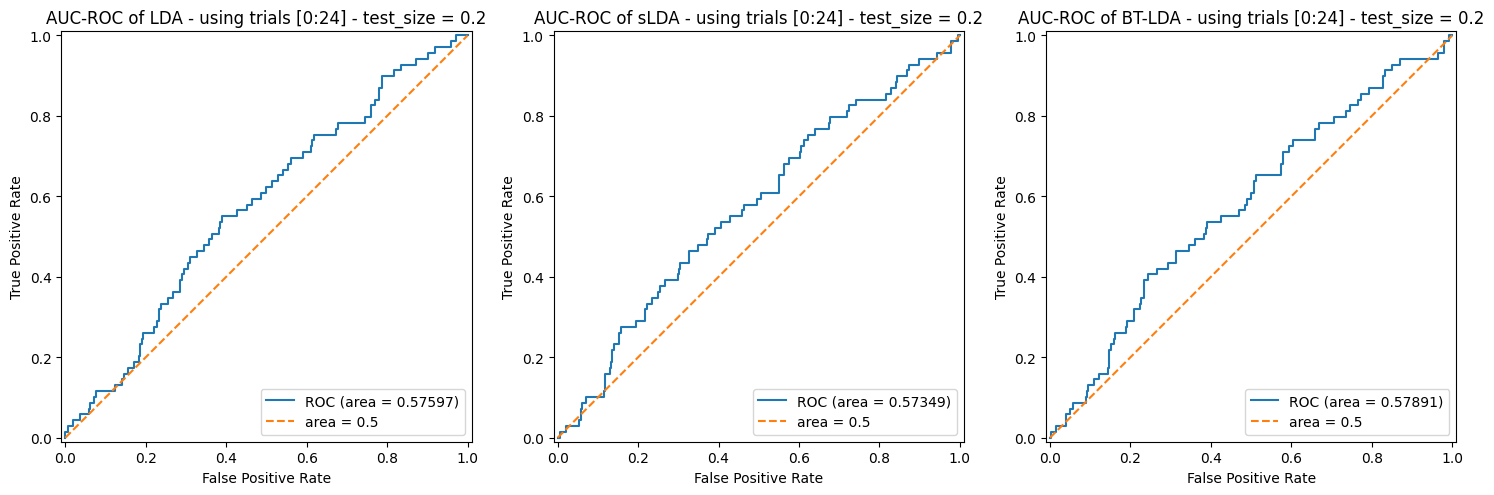

In [11]:
# trials 0-24
compare_auc_single_trial_interval(trials_s3,0,24,test_size=0.2,plot_roc_curves=True) 

## Session 16

### Loading & preprocessing

In [5]:
# Load all runs of session 16
data_path_test = "data_p1/P1_S16/anonymized" 
trials, iterations, epochs = load_session_chached(data_path_test)
# for p1 s16, first runtime is 6 min 25 s
# for p1 s16, second runtime is 10 s
print(len(trials))
print(all_have_same_condition(data_path_test, show_conditions=True))


Loading file:  data_p1_P1_S16_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S16_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S16_anonymized.pkl
162
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350']
True


In [13]:
# visualize / inspect data
inspect_session("data_p1/P1_S16/anonymized")

Condition per run: 
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350']
All conditions of this session are the same:  True
Number of iterations per trial:
Run 0: [15  8  8  8  8  8]
Run 1: [ 8  8  8  8  8 13]
Run 2: [ 8  8  8  8 10  8]
Run 3: [8 8 8 8 8 8]
Run 4: [ 8  8  8  8  8 15]
Run 5: [8 8 8 8 8 8]
Run 6: [ 8 11  8  8  8  8]
Run 7: [ 8  8  8 10  8  8]
Run 8: [8 8 8 8 8 8]
Run 9: [15 14  8  8  8  8]
Run 10: [ 8  8 15  8 15  9]
Run 11: [ 8  8 11  8 15  8]
Run 12: [ 8 15  8  8 14 15]
Run 13: [8 8 8 8 8 8]
Run 14: [ 8 15  8 15  8  8]
Run 15: [8 8 8 8 8 8]
Run 16: [8 8 8 9 8 8]
Run 17: [8 8 8 8 8 8]
Run 18: [ 8  8  8  8 12  8]
Run 19: [ 8  8  8  8 10 11]
Run 20: [ 8 15 10  8  9  8]
Run 21: 

### Calibration / offline performance

948 epochs were used
AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.9222705696202531
AUC SLDA:  0.9317642405063292


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


AUC BT-LDA:  0.9515427215189873


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


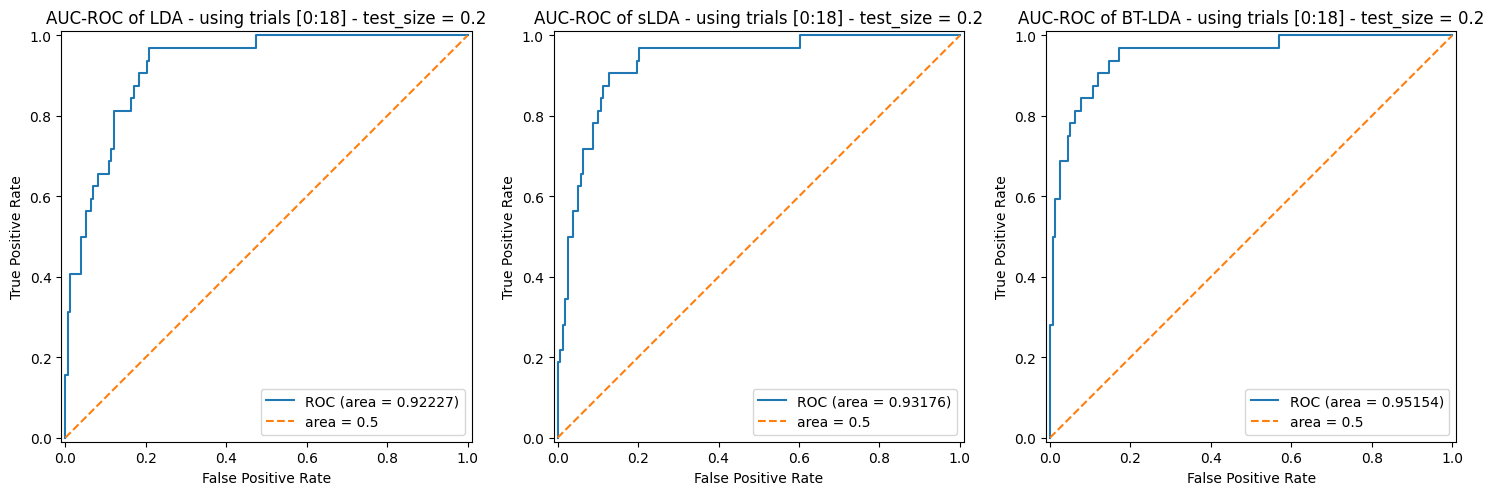

In [10]:
# Evaluating the calibration / offline performance
# using the time intervals [0.1, 0.2, 0.3, 0.4, 0.5] (Default)
print("{} epochs were used".format(get_n_epochs(trials=trials[:18])))
compare_auc_single_trial_interval(trials,0,18,test_size=0.2,plot_roc_curves=True)


In [12]:
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, start=0, stop=18, ival_bounds=clf_ival_boundaries, cv_folds = 4)

Using 4-fold cross-validation:
Mean AUC score of LDA: 		 0.8711494336177077
Mean AUC score of sLDA: 	 0.8969877086628355
Mean AUC score of BT-LDA: 	 0.8967507793015408


#### Using smaller time intervals

In [16]:
# LDA vs SLDA vs BT-LDA
clf_ival_boundaries = np.arange(0.1,0.5,0.02)
print(clf_ival_boundaries)

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, start=0, stop=18, ival_bounds=clf_ival_boundaries, cv_folds = 4)

# Using different time intervals  
clf_ival_boundaries = np.arange(0.05,0.5,0.01)
print("\n",clf_ival_boundaries)

# Using cv
print("Using 4-fold cross-validation:")
compute_auc_with_cv(trials, start=0, stop=18, ival_bounds=clf_ival_boundaries, cv_folds = 4)


[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48]
Using 4-fold cross-validation:
Mean AUC score of LDA: 		 0.6740371632503612
Mean AUC score of sLDA: 	 0.8709951098910489
Mean AUC score of BT-LDA: 	 0.8797369356062249

 [0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18
 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32
 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46
 0.47 0.48 0.49]
Using 4-fold cross-validation:
Mean AUC score of LDA: 		 0.6388372449603414
Mean AUC score of sLDA: 	 0.8699995201264237
Mean AUC score of BT-LDA: 	 0.8868781857360538


## Online simulation


#### Some information about the variables:
- `online_trial_targets` contains the target word id ($[1,2, ..,6]$) per trial. These should **only** be used to quantify the performance.
- `online_labels` contains whether the presented stimulus/word is a target (1) or a non-target (0). Note that the order of stimuli differs per iteration.
- `online_words` contains the word id ($[1,2, ..,6]$) per stimulus/word presentation. 

1. Inspect the code given below. In this code the classifier predicts the signed distance to the decision boundary, given a single presented stimulus/word. You will build on top of this code, so make sure you understand the three variables listed above.

1. **Condition A: no dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial, using the entire trial information. In other words, keep track of the **signed distances** to the decision hyperplane per word id throughout the entire trial to make a single prediction about the target word after all 15 iterations. Report your prediction accuracy. 
**NOTE**: The order in which words are presented differs per iteration in a trial. Also note that the classifier tried to learn a decision hyperplane such that targets have a positive signed distance to the hyperplane, and non-targets have a negative signed distance to the hyperplane.

#### Function

In [127]:
import logging
import math
# previous runtime 2 m 10 s
# previous previous runtime 2 m 50 s
# first runtime 4 mins

# 2nd runtime after del sessions_s3, iterations_s3, epochs_s3: 2.5 mins
# copied from A7 notebook, with changes implemeted

def online_simulation(raw_calibration_trials, online_trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), log_process=None):

    if log_process is not None:
        # this was needed in order to create a log file
        for handler in logging.root.handlers[:]:
            logging.root.removeHandler(handler)

        logging.basicConfig(
            filename=log_process,
            encoding="utf-8",
            filemode="w", # 'a' to not overwrite current log, 'w' to overwrite. This setting can be changed later
            level=logging.DEBUG)

        logging.info("New log file")


    clf_ival_boundaries = ival_bounds
    # raw_calibration_trials = trials[0:12] # change start & stop trial
    # online_trials = trials[12:] 
    raw_calibration_trials = raw_calibration_trials

    ### Training the classifier ---------------------------------------------------------

    # calibration_trials = [[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials]
    # calibration_trials_reshaped = [[epochs.transpose(0, 2, 1) for epochs in trial] for trial in calibration_trials]
    # calibration_stimuli = list()
    # for trial in calibration_trials_reshaped:
    #     for iteration in trial:
    #         for epoch in iteration:
    #             calibration_stimuli.append(epoch.reshape(-1)) 
    # calibration_stimuli = np.array(calibration_stimuli)
    # calibration_labels = list()
    # for trial in raw_calibration_trials:
    #     for iteration in trial:
    #         for event in iteration.events[:,2]:
    #             calibration_labels.append(1 if event > 107 else 0)
    # calibration_labels = np.array(calibration_labels) 
    # X = calibration_stimuli
    # y = calibration_labels

    calibration_trials = [[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials]
    calibration_trials_reshaped = [[epochs.transpose(0, 2, 1) for epochs in trial] for trial in calibration_trials]
    calibration_stimuli = [epoch.reshape(-1) for trial in calibration_trials_reshaped for iteration in trial for epoch in iteration]
    calibration_stimuli = np.array(calibration_stimuli)
    calibration_labels = [(1 if event > 107 else 0) for trial in raw_calibration_trials for iteration in trial for event in iteration.events[:,2]] 
    calibration_labels = np.array(calibration_labels) 
    X = calibration_stimuli
    y = calibration_labels

    # Evaluation of ex. 3 

    ### LDA
    ldaclf = make_pipeline(LDA(),)
    ldaclf.fit(X,y)
    #print(ldaclf.get_params)

    ### Shrinkage LDA
    slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    slda.fit(X,y)

    ### BT-LDA
    # problem: we have 63 channels in s1,s2 but 31 channels in the other sessions.
    # nch = (trials[0][0]).info["nchan"]
    nch = (raw_calibration_trials[0][0]).info["nchan"]
    btlda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
    )
    btlda.fit(X,y)

    if log_process:
        logging.info("Trained all three classifiers on the calibration data.")
        logging.info("Online simulation starts")

    ### Online simulation ------------------------------------------------------------------

    # Extract relevant data, labels and the played words

    # Using list comprehension
    online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
    online_labels = [(1 if event > 107 else 0) for trial in online_trials for iteration in trial for event in iteration.events[:,2]]            
    online_labels = np.array(online_labels) # conversion to np array is maybe not even needed
    online_words = [(iteration.events[:,2]%10) for trial in online_trials for iteration in trial]
    online_words = np.array(online_words) # conversion to np array is maybe not even needed

    # online_trial_targets: the target word per trial
    # print(len(online_trial_targets)) # e.g. 150
    # print(online_trial_targets[:10]) # e.g. [4 5 6 2 3 1 1 6 2 4]

    # online_labels: the location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
    # print(len(online_labels)) # e.g. 8244 = labels of all epochs (= n_trials * n_iterations per trial * n_epochs per iteration)
    # print(online_labels[:18]) # e.g. [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
   
    # #online_words: The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.
    # print(len(online_words)) # e.g. 1374
    #print(online_words[:6]) # e.g. [[1 6 2 3 5 4]
                             #       [6 3 1 2 4 5]
                             #       [6 3 5 2 1 4]
                             #       [3 1 2 6 4 5]
                             #       [1 6 5 2 4 3]
                             #       [5 4 1 6 2 3]]
    print(online_words.shape)

    if log_process:
        logging.info("Number of online trials: {}, which is {} runs".format(len(online_trials), len(online_trials)/6))


    # Predict target/non-target per stimulus.

    signed_distances_lda = np.zeros(len(online_labels))
    signed_distances_slda = np.zeros(len(online_labels))
    signed_distances_btlda = np.zeros(len(online_labels))

    count = 0 
    for t, trial in enumerate(online_trials):
        print("trial {}/{}".format(t, len(online_trials)))
        if log_process:
            logging.info("------------------ Run {} Trial {} ------------------".format(math.trunc(t/6)+1,t+1))
            logging.info("{epoch} \t| {word_id} \t| {LDA} \t| {SLDA} \t| {BTLDA} ")
        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):
                s1 = (ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)))[0]
                signed_distances_lda[count] = s1 # Compute signed distance of stimulus to decision boundary

                s2 = (slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)))[0]
                signed_distances_slda[count] = s2 # Compute signed distance of stimulus to decision boundary

                s3 = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item()
                signed_distances_btlda[count] = s3 # Compute signed distance of stimulus to decision boundary
                
                if log_process:
                    logging.info("{} \t| {} \t| {} \t| {} \t| {}".format(count, iteration[s].events[:,2], s1, s2, s3))
                    
                count+=1
                if count ==1:
                    print(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).shape)
                # Important note during debugging
                # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)

    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_lda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the LDA classifier [online]")
    plt.show()


    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_slda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the sLDA classifier [online]")
    plt.show()


    fpr, tpr, thresholds = metrics.roc_curve(online_labels,signed_distances_btlda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
    plt.show()

    return online_trial_targets


#### Function call

trial 0/72
trial 1/72
trial 2/72
trial 3/72
trial 4/72
trial 5/72
trial 6/72
trial 7/72
trial 8/72
trial 9/72
trial 10/72
trial 11/72
trial 12/72
trial 13/72
trial 14/72
trial 15/72
trial 16/72
trial 17/72
trial 18/72
trial 19/72
trial 20/72
trial 21/72
trial 22/72
trial 23/72
trial 24/72
trial 25/72
trial 26/72
trial 27/72
trial 28/72
trial 29/72
trial 30/72
trial 31/72
trial 32/72
trial 33/72
trial 34/72
trial 35/72
trial 36/72
trial 37/72
trial 38/72
trial 39/72
trial 40/72
trial 41/72
trial 42/72
trial 43/72
trial 44/72
trial 45/72
trial 46/72
trial 47/72
trial 48/72
trial 49/72
trial 50/72
trial 51/72
trial 52/72
trial 53/72
trial 54/72
trial 55/72
trial 56/72
trial 57/72
trial 58/72
trial 59/72
trial 60/72
trial 61/72
trial 62/72
trial 63/72
trial 64/72
trial 65/72
trial 66/72
trial 67/72
trial 68/72
trial 69/72
trial 70/72
trial 71/72


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


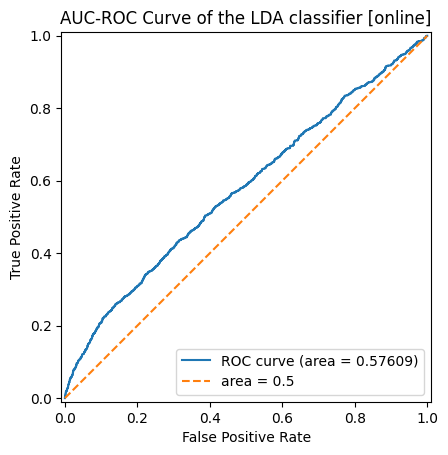

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


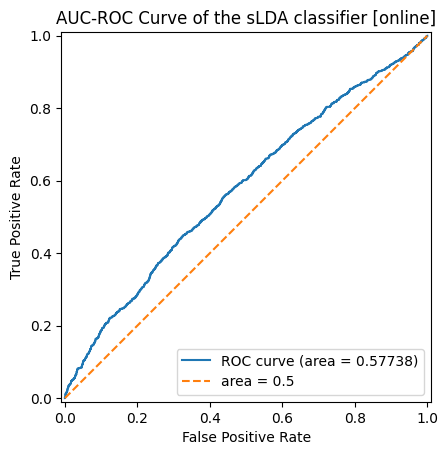

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


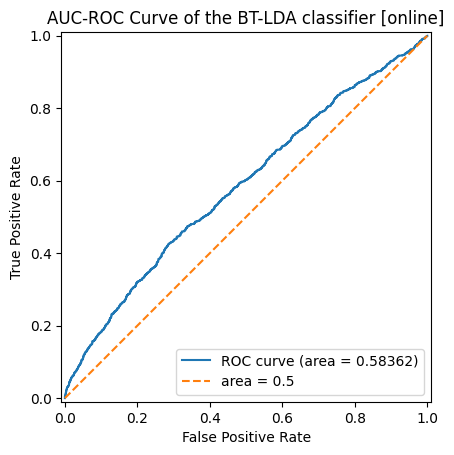

CPU times: total: 45.6 s
Wall time: 45.9 s


In [68]:
# 08-05-2025 09:27 further optimizing, code cleanup
# timeit outcome
# 54.1 s ± 893 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

calibration_trials = trials[0:12]
online_trials = trials[12:]
%time online_trial_targets = online_simulation(calibration_trials, online_trials)


## Real online simulation

In [109]:
# import logging
# to do: add timestap in log

import logging

# this was needed in order to create a log file
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename="tester_log.log",
    encoding="utf-8",
    filemode="w", # 'a' to not overwrite current log, 'w' to overwrite. This setting can be changed later
    level=logging.DEBUG)

logging.info("New log file")


### Simulate session 3 (trained on sessions 1 and 2)

Procedure
1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.
2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)
3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3

Loading file:  data_p1_P1_S1_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  data_p1_P1_S2_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl

Trials of session 1:  12
Trials of session 2:  18
All calibration trials:  30
That is 2700 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5307901234567901
AUC SLDA:  0.5837037037037037
AUC BT-LDA:  0.5758271604938271


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


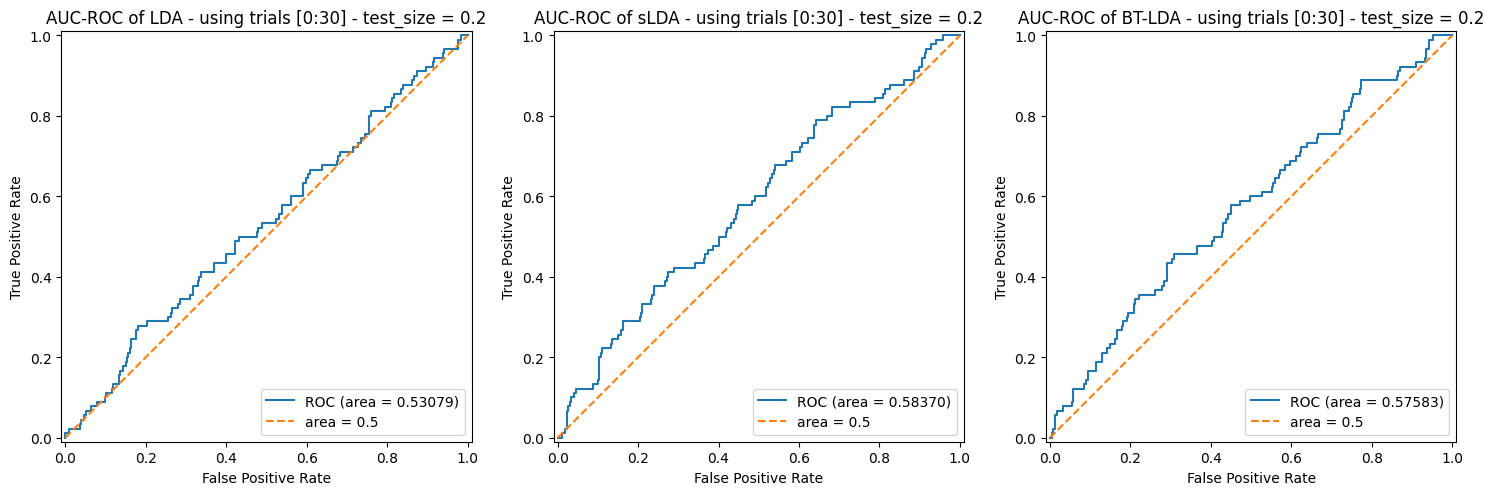

Mean AUC score of LDA: 		 0.5706606665905883
Mean AUC score of sLDA: 	 0.5926908362969345
Mean AUC score of BT-LDA: 	 0.5937643368563904


In [95]:
# 1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.

trials_s1, iterations_s1, epochs_s1 = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
trials_s2, iterations_s2, epochs_s2 = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)

print("\nTrials of session 1: ",len(trials_s1))
print("Trials of session 2: ",len(trials_s2))

calibration_trials = trials_s1 + trials_s2
print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

del trials_s1
del trials_s2

# 2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
trial 0/84
(1, 4, 31)
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


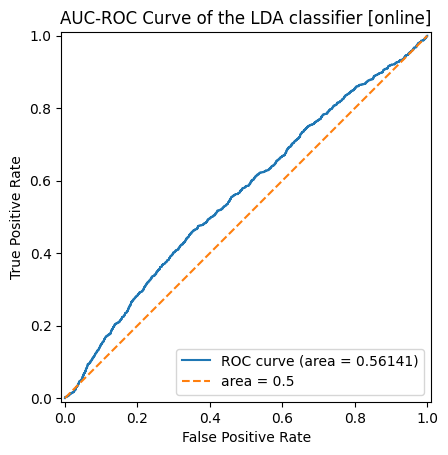

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


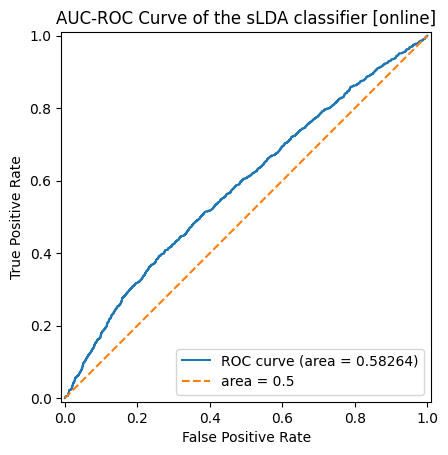

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


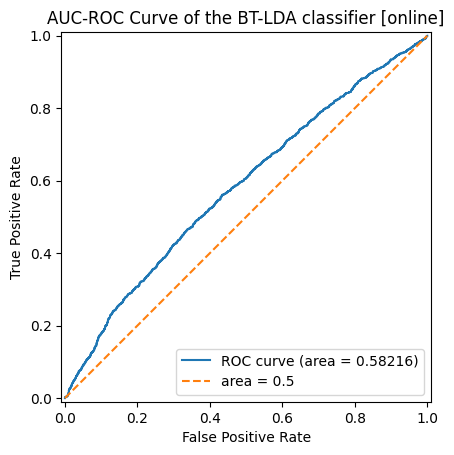

In [ ]:
# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3
# runtime 1 min
trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s3)


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
(1197, 6)
trial 0/84
(1, 4, 31)
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84

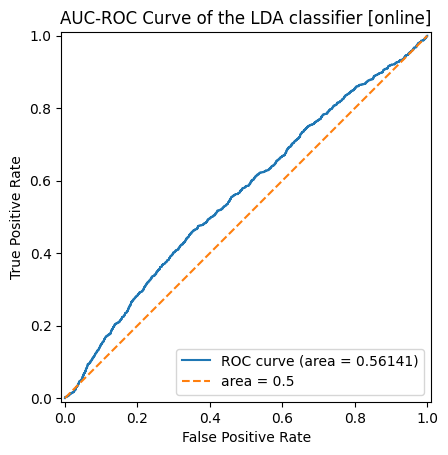

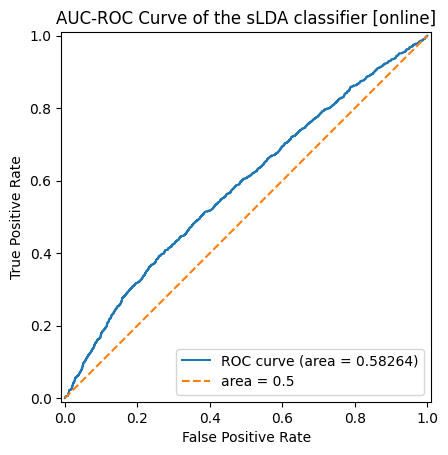

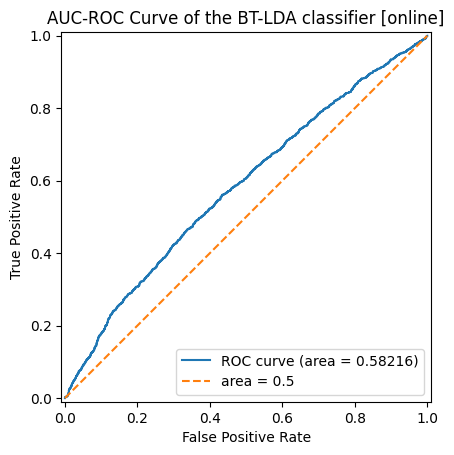

In [128]:
# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3
# runtime 1 min
trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_test_s3")
